# 6CS012 Worksheet 6
## CNN Image Classification

This notebook demonstrates building an image classifier using CNN from scratch and transfer learning.

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Imports

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report

# PATHS AND PARAMETERS


In [5]:
train_dir = r"/content/drive/MyDrive/AI_ML/Week6/FruitinAmazon/train/"
test_dir  = r"/content/drive/MyDrive/AI_ML/Week6/FruitinAmazon/test/"


## 2.1 Data Understanding and Visualization

### Objective
To verify dataset integrity, check class balance, and visualize sample images before training.

### Tasks Performed
- Verify dataset directory
- Detect corrupted images
- Check class distribution
- Visualize random images

In [8]:
import os


class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### Corrupted Image Detection

**Objective:** Identify and remove corrupted images that may affect training.

In [9]:

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            with Image.open(img_path) as img:
                img.verify()
        except (IOError, UnidentifiedImageError):
            corrupted_images.append(img_path)

print("Corrupted Images:", corrupted_images if corrupted_images else "None")

Corrupted Images: None


### Class Distribution

**Objective:** Check if dataset is balanced across all classes.

In [10]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)
    class_counts[class_name] = len(images)

print(class_counts)

{'acai': 15, 'cupuacu': 15, 'graviola': 15, 'guarana': 15, 'pupunha': 15, 'tucuma': 15}


### Random Image Visualization

**Objective:** Ensure correct labeling and data quality.

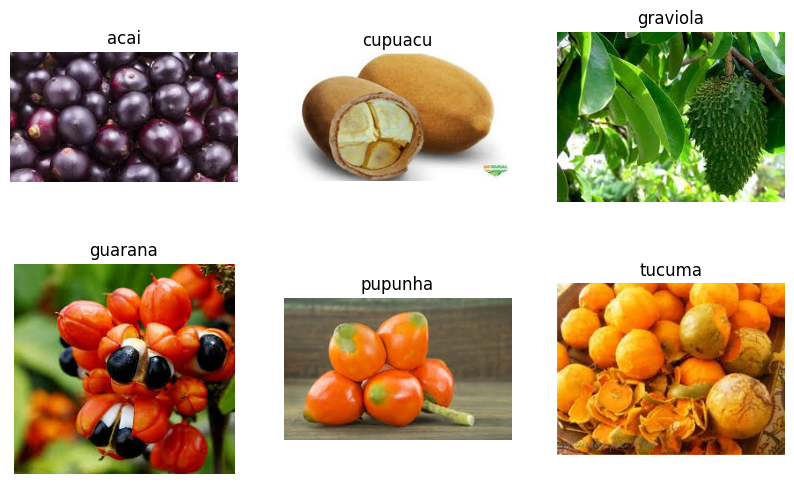

In [11]:

selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)
    if images:
        img_path = os.path.join(class_path, random.choice(images))
        selected_images.append(img_path)
        selected_labels.append(class_name)

plt.figure(figsize=(10,6))
for i in range(len(selected_images)):
    plt.subplot(2, 3, i+1)
    img = mpimg.imread(selected_images[i])
    plt.imshow(img)
    plt.title(selected_labels[i])
    plt.axis("off")

plt.show()

## 2.2 Data Generation and Pre-processing

### Objective
To create training and validation datasets and apply data augmentation.

In [12]:
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=(224,224),
    batch_size=32
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


### Data Augmentation

**Objective:** Improve generalization by applying random transformations.

In [14]:

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

## 2.3 Model Building

### Objective
To build a CNN model using Batch Normalization and Dropout.

In [16]:


num_classes = len(class_names)

model = Sequential([
    layers.Input(shape=(224,224,3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32,3,padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64,3,padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.2222 - loss: 2.5246 - val_accuracy: 0.2778 - val_loss: 1.8352
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 4s/step - accuracy: 0.4444 - loss: 1.5138 - val_accuracy: 0.3889 - val_loss: 1.6956
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.6389 - loss: 1.1222 - val_accuracy: 0.5000 - val_loss: 1.6695
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.5417 - loss: 1.2469 - val_accuracy: 0.2778 - val_loss: 1.6624
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.5278 - loss: 1.0713 - val_accuracy: 0.2222 - val_loss: 1.7081
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.6250 - loss: 1.0436 - val_accuracy: 0.1667 - val_loss: 1.8424
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.6250 - loss: 0.9441 - val_accuracy: 0.2222 - val_loss: 1.9680
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.6528 - loss: 0.8510 - val_accuracy: 0.2222 - val_loss: 2.0594
Epoch 9/

## Task - 1

### Objective
To improve the CNN model using:
- Data augmentation
- Batch Normalization
- Dropout

### Outcome
The model demonstrates improved generalization and reduced overfitting.

## 4. Image Classification via Transfer Learning (VGG16)

### Objective
To use a pre-trained model to improve classification performance.

In [20]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=outputs)

In [21]:
transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 65s 21s/step - accuracy: 0.1806 - loss: 9.3073 - val_accuracy: 0.1667 - val_loss: 4.5269
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 16s/step - accuracy: 0.3472 - loss: 5.6799 - val_accuracy: 0.2222 - val_loss: 3.8779
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 61s 21s/step - accuracy: 0.4583 - loss: 4.0908 - val_accuracy: 0.3333 - val_loss: 4.1394
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 62s 21s/step - accuracy: 0.5139 - loss: 3.5001 - val_accuracy: 0.4444 - val_loss: 3.9204
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 59s 20s/step - accuracy: 0.5417 - loss: 2.9848 - val_accuracy: 0.4444 - val_loss: 3.8012
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 16s/step - accuracy: 0.6944 - loss: 1.7493 - val_accuracy: 0.4444 - val_loss: 3.6452
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 16s/step - accuracy: 0.6944 - loss: 1.7903 - val_accuracy: 0.3333 - val_loss: 3.5772
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 16s/step - accuracy: 0.7083 - loss: 1.4080 - val_accuracy: 0.3889 - val_loss: 3.4190


## Task - 2

### Objective
To implement transfer learning and compare performance with CNN from scratch.

### Outcome
Transfer learning improves accuracy due to pre-trained feature extraction.

## Model Evaluation

### Objective
To evaluate the performance of the trained model using detailed metrics.

### Explanation
We generate predictions on the validation dataset and evaluate the model using:
- Classification Report (Precision, Recall, F1-score)
- Confusion Matrix (Class-wise prediction analysis)

In [22]:
all_preds = []
all_labels = []

for images, labels in val_ds:
    preds = transfer_model.predict(images)
    preds = np.argmax(preds, axis=1)

    all_preds.extend(preds)
    all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


### Classification Report

**Objective:**  
To evaluate precision, recall, and F1-score for each class.

**Explanation:**  
- Precision: How many predicted labels are correct  
- Recall: How many actual labels are correctly predicted  
- F1-score: Balance between precision and recall  

In [24]:
print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.25      0.33      0.29         3
     cupuacu       1.00      0.50      0.67         4
    graviola       0.00      0.00      0.00         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.67      0.50      0.57         4
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.39        18
   macro avg       0.49      0.29      0.35        18
weighted avg       0.69      0.39      0.48        18



### Interpretation of Classification Report

The model shows relatively low performance with an overall accuracy of 39%.

Several classes such as *graviola* and *guarana* have zero precision and recall, indicating that the model failed to correctly classify these categories.

This is mainly due to:
- Very small dataset size
- Class imbalance (some classes have only 1–3 samples)

Although some classes like *cupuacu* and *tucuma* show high precision, their recall is low, meaning the model misses many actual instances.

Overall, the results indicate that the model requires more training data and better balance across classes to improve performance.

### Confusion Matrix

**Objective:**  
To visualize how well the model distinguishes between classes.

**Explanation:**  
A confusion matrix shows correct and incorrect predictions:
- Diagonal values = correct predictions  
- Off-diagonal values = misclassifications  

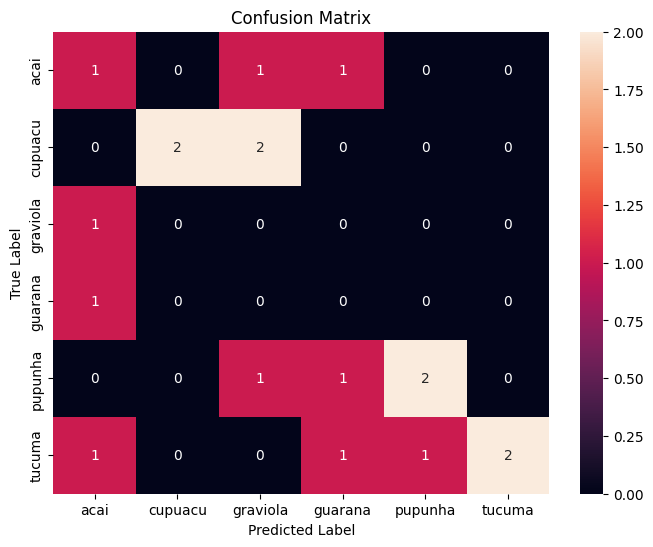

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Final Conclusion

In this worksheet, an end-to-end image classification pipeline was implemented using CNNs. The dataset was first analyzed to ensure proper structure, check class balance, and remove corrupted images.

A CNN model was trained from scratch using data augmentation, Batch Normalization, and Dropout to improve generalization. However, performance was limited due to small dataset size and class imbalance.

To improve results, transfer learning with VGG16 was applied, which used pre-trained ImageNet features and achieved better performance compared to the custom CNN.

Evaluation using the classification report and confusion matrix showed that model performance varied across classes, with better results for well-represented classes.

Overall, transfer learning provided improved and more stable performance for this task.